In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as mticker
import statsmodels.api as sm

COMBINED_PATH = "../local/Tvarminne/combined/combined.csv"

df = pd.read_csv(COMBINED_PATH, engine='pyarrow', index_col="Time")



In [127]:
col_hue = "bloom24"

def scatter_reg(x, y, **kwargs):
    ax = plt.gca()
    
    # Keep only positive values
    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 2:
        # Not enough points to fit regression
        sns.scatterplot(x=x, y=y, ax=ax, **kwargs)
        return

    # Transform data for log-log regression
    x_log = np.log(x)
    y_log = np.log(y)

    # Fit linear regression in log-log space
    X = sm.add_constant(x_log)
    model = sm.OLS(y_log, X).fit()
    
    # Generate prediction line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.exp(model.predict(sm.add_constant(np.log(x_line))))
    
    # Set log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Keep only positive values for limits
    x_pos = x[x > 0]
    y_pos = y[y > 0]

    if len(x_pos) > 0:
        xmin = x_pos.min()
        xmax = x_pos.max()

        # Add small padding
        pad = 0.05
        ax.set_xlim(xmin * (1 - pad), xmax * (1 + pad))

    if len(y_pos) > 0:
        ymin = y_pos.min()
        ymax = y_pos.max()

    pad = 0.05
    ax.set_ylim(ymin * (1 - pad), ymax * (1 + pad))

    # Formatting
    ax.xaxis.set_major_locator(mticker.LogLocator(numticks=4))
    ax.yaxis.set_major_locator(mticker.LogLocator(numticks=4))
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

    # Plot regression line
    ax.plot(x_line, y_line)

    # Plot scatter plot
    sns.scatterplot(x=x, y=y, ax=ax, **kwargs)

0
FCH4_nmolm2s vs FCO2Li_umolm2s: 383 valid rows
FCH4_nmolm2s vs dms_ppt: 376 valid rows
FCH4_nmolm2s vs MSA_moleccm3: 379 valid rows
FCH4_nmolm2s vs IA_moleccm3: 337 valid rows
FCH4_nmolm2s vs isp_ppt: 373 valid rows
FCH4_nmolm2s vs mts_ppt: 376 valid rows
FCH4_nmolm2s vs neg0p8t2_ptcm3: 383 valid rows
FCH4_nmolm2s vs neg2t2p3_ptcm3: 381 valid rows
FCH4_nmolm2s vs ionRatio_x: 380 valid rows
FCO2Li_umolm2s vs dms_ppt: 1193 valid rows
FCO2Li_umolm2s vs MSA_moleccm3: 1492 valid rows
FCO2Li_umolm2s vs IA_moleccm3: 1414 valid rows
FCO2Li_umolm2s vs isp_ppt: 1191 valid rows
FCO2Li_umolm2s vs mts_ppt: 1196 valid rows
FCO2Li_umolm2s vs neg0p8t2_ptcm3: 1548 valid rows
FCO2Li_umolm2s vs neg2t2p3_ptcm3: 1543 valid rows
FCO2Li_umolm2s vs ionRatio_x: 1541 valid rows
dms_ppt vs MSA_moleccm3: 1112 valid rows
dms_ppt vs IA_moleccm3: 1037 valid rows
dms_ppt vs isp_ppt: 1193 valid rows
dms_ppt vs mts_ppt: 1198 valid rows
dms_ppt vs neg0p8t2_ptcm3: 1181 valid rows
dms_ppt vs neg2t2p3_ptcm3: 1180 valid r

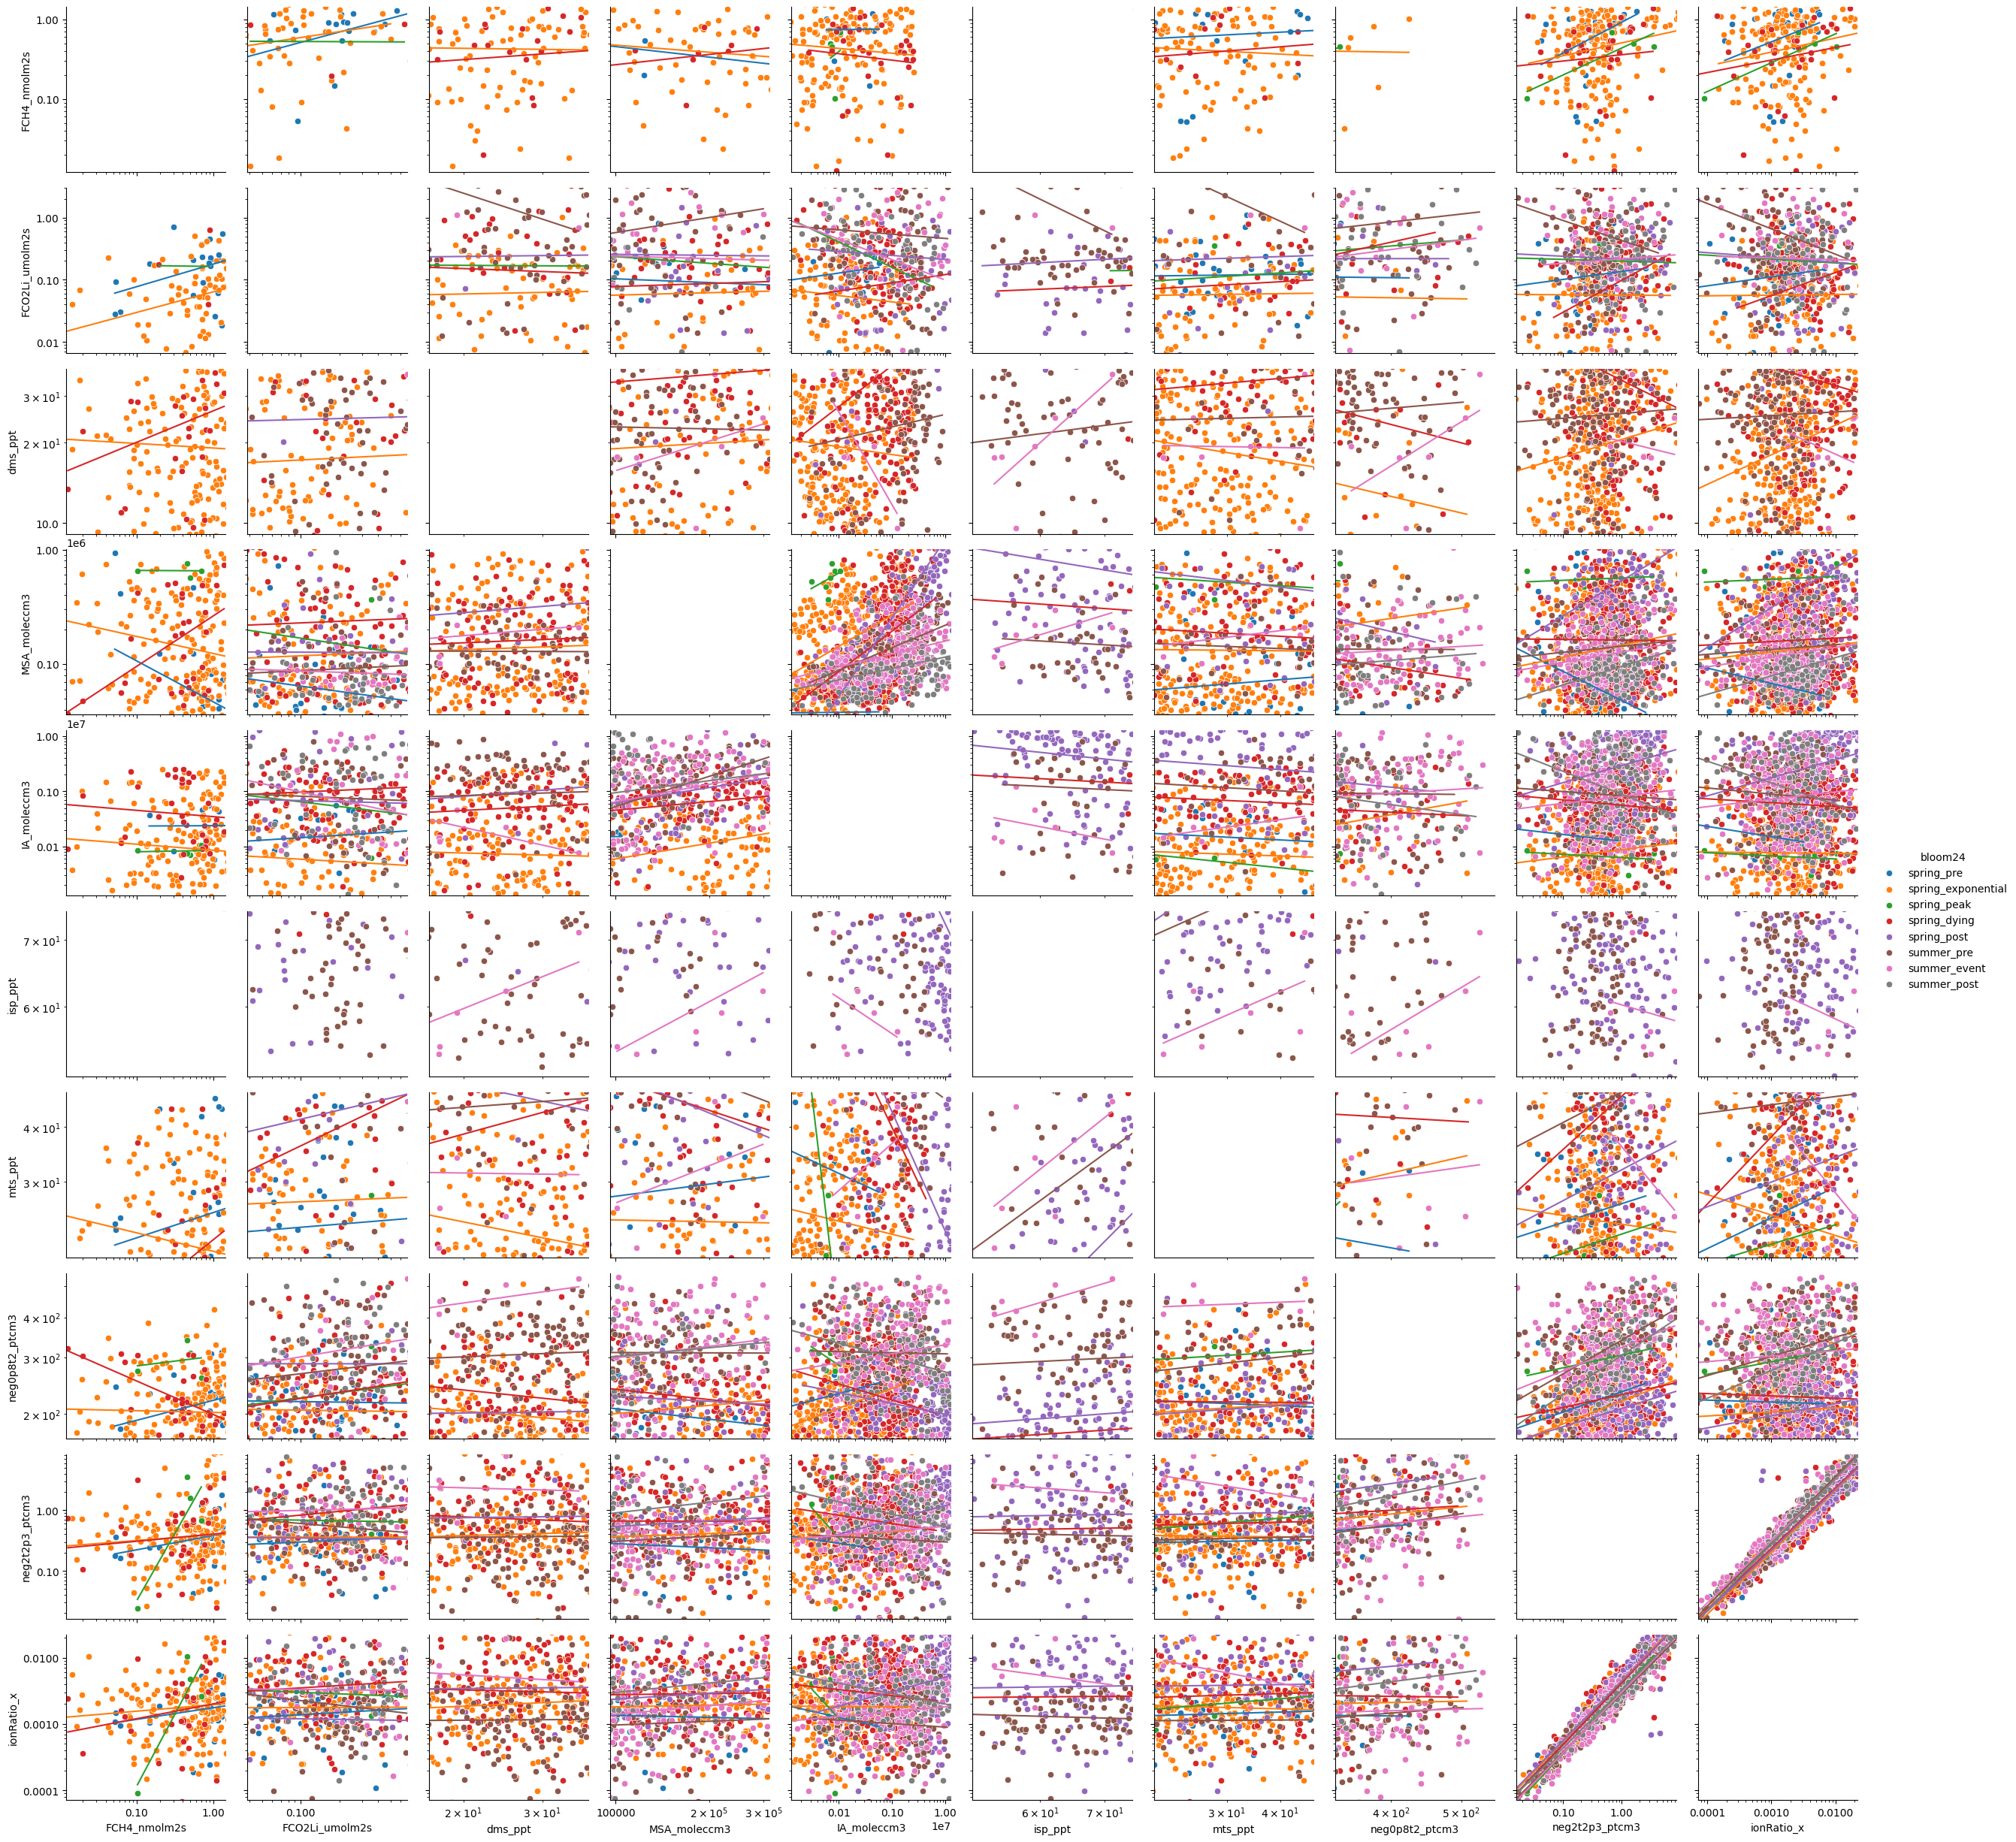

In [128]:
bloom_types = [
    "spring_pre",
    "spring_exponential",
    "spring_peak",
    "spring_dying",
    "spring_post",
    "summer_pre",
    "summer_event",
    "summer_post"
]

mask_sea = df["WindSector"] == "sea"
mask_bloom = df["bloom24"].isin(bloom_types)

df_sea_bloom24 = df[mask_sea & mask_bloom]

cols_by_bloomt_scatter = ["FCH4_nmolm2s", "FCO2Li_umolm2s", "dms_ppt", "MSA_moleccm3", "IA_moleccm3", "isp_ppt", "mts_ppt", "neg0p8t2_ptcm3", "neg2t2p3_ptcm3", "ionRatio_x"]

print((df["bloom24"] == "summer1_dying").sum())

# Count valid rows for each pair
cols = cols_by_bloomt_scatter


# number of valid pairs
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        n_valid = df_sea_bloom24[[c1, c2, col_hue]].dropna().shape[0]
        print(f"{c1} vs {c2}: {n_valid} valid rows")

# 

# df_pairplot = df_sea_bloom24[cols_by_bloomt_scatter + [col_hue]].dropna(
#     subset=cols_by_bloomt_scatter + [col_hue])


g = sns.PairGrid(df_sea_bloom24, vars=cols_by_bloomt_scatter, hue=col_hue)
# g.map_offdiag(sns.scatterplot)                     # scatterplots for off-diagonal
g.map_lower(scatter_reg)
# g.map_diag(sns.histplot, log_scale=True, stat="percent", bins=10)
g.map_upper(scatter_reg)
g.add_legend(title=col_hue)   
plt.savefig("rainbow1.png")
plt.show()


In [129]:
cols_to_rainbow = {
    
}